# Crime Analysis in Los Angeles (2020–2025)🔪🩸
---

## Introduction 
__Introduction to the topic__ 

Crime affects communities, public safety and decision-making every day. This project analyzes crime incidents reported by the Los Angeles Police Department between 2020 and 2025. The dataset includes information about the date, time, area and type of each reported crime. By exploring these records, this project aims to identify crime patterns and provide insights that support better public safety decisions. insights that can help for a better public safety decisions!

---

## Problem Statement

Between 2020 and 2025, more than one million crime incidents were reported across 21 areas in Los Angeles. With such a large number of crime incidents, it is difficult to identify the areas, times, and crime types that require the most attention.
Therefor, by analyzing crime patterns, this project aims to provide data based insights that can support more effective resource allocation and crime prevention strategies.

## Objectives:
__Questions that will guide the analysis to solve the problem__

- What are the most common types of crimes reported in Los Angeles?
- Which areas recorded the highest number of crime incidents?
- How have crime incidents changed between 2020 and 2025?
- At what times of the day are crimes reported most frequently?
- What are the most common crime types within the areas with the highest number of reported incidents?
---

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [1]:
import pandas as pd

df = pd.read_csv('Crime_Data_from_2020_to_Present-selected-columns.csv')
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER)
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN
...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN
1005194,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B..."
1005195,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY
1005196,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN


In [2]:
df.shape

(1005198, 10)

In [3]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 10 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   DR_NO        1005198 non-null  int64
 1   Date Rptd    1005198 non-null  str  
 2   DATE OCC     1005198 non-null  str  
 3   TIME OCC     1005198 non-null  int64
 4   AREA         1005198 non-null  int64
 5   AREA NAME    1005198 non-null  str  
 6   Rpt Dist No  1005198 non-null  int64
 7   Part 1-2     1005198 non-null  int64
 8   Crm Cd       1005198 non-null  int64
 9   Crm Cd Desc  1005198 non-null  str  
dtypes: int64(6), str(4)
memory usage: 139.4 MB


In [5]:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd
count,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06
mean,2.202277e+08,1.339911e+03,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02
std,1.320282e+07,6.510531e+02,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02
50%,2.209160e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02
75%,2.311105e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02


In [6]:
# this is the only way it works without the kernel suting down and dying!

In [7]:
df['Year'] = df['DATE OCC'].str.split().str[0].str.split('/').str[2]

In [8]:
# this is for the 4th objective about the time of the day

In [9]:
df['Hour'] = df['TIME OCC'] // 100


df[['TIME OCC', 'Hour']].head(10)

,TIME OCC,Hour
0,2130,21
1,1800,18
2,1700,17
3,2037,20
4,630,6
5,1800,18
6,1340,13
7,1210,12
8,2030,20
9,2300,23


In [10]:
df['Time of Day'] = ''

df.loc[(df['Hour'] >= 5) & (df['Hour'] < 12), 'Time of Day'] = 'Morning'

df.loc[(df['Hour'] >= 12) & (df['Hour'] < 17), 'Time of Day'] = 'Afternoon'

df.loc[(df['Hour'] >= 17) & (df['Hour'] < 21), 'Time of Day'] = 'Evening'

df.loc[(df['Hour'] >= 21) | (df['Hour'] < 5), 'Time of Day'] = 'Night'

# this is for the timing to make it easier on the graph

### Observations

- The dataset contains 1,005,198 rows and 10 columns.
- The dataset includes both numerical and categorical variables.
- No missing values were found in the selected columns.
- A Year column was extracted from the DATE OCC column to analyze crime trends over time.
- The dataset contains enough information to analyise crime patterns by location, time and crime type.

### Data Handling: 
__Cleaning, transforming, and combining data__

In [11]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1005193    False
1005194    False
1005195    False
1005196    False
1005197    False
Length: 1005198, dtype: bool

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

DR_NO          0
Date Rptd      0
DATE OCC       0
TIME OCC       0
AREA           0
AREA NAME      0
Rpt Dist No    0
Part 1-2       0
Crm Cd         0
Crm Cd Desc    0
Year           0
Hour           0
Time of Day    0
dtype: int64

###  Observation:

- No duplicate records were found.
- No missing values were found in the selected columns

### Analysis: 
__Answering the objectives through data analysis__



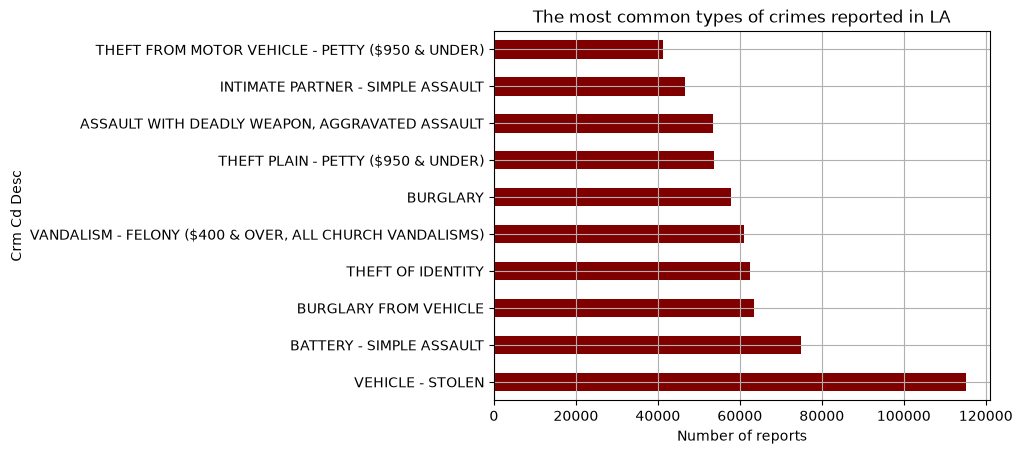

In [14]:
df['Crm Cd Desc'].value_counts().head(10).plot(kind = 'barh', color='maroon',
                                               title = 'The most common types of crimes reported in LA',
                                              xlabel='Number of reports',
                                               grid = True);

### Interpretation 1:
Vehicle theft was the most frequently reported crime in LA, with almost 115500 incidents. It was followed by the battery-simple assault and burlgary from vehicles.

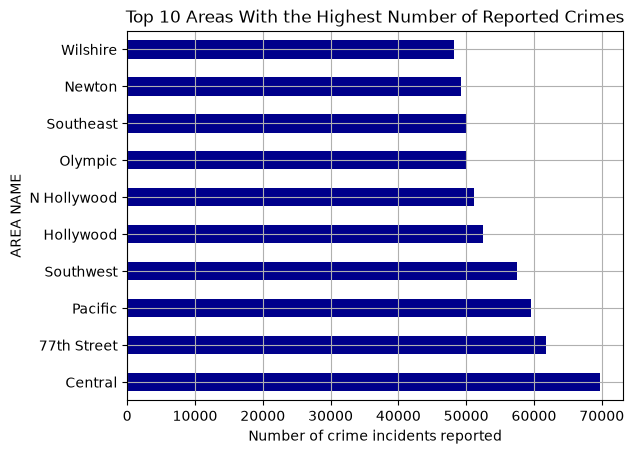

In [15]:
df['AREA NAME'].value_counts().head(10).plot(kind = 'barh', color='darkblue',
                                               title = 'Top 10 Areas With the Highest Number of Reported Crimes',
                                              xlabel='Number of crime incidents reported',
                                               grid = True);

### Interpretation 2:

Central recorded the highest number of reported crimes, followed by 77th Street and Pacific. These areas had more reported crimes than the other areas in the dataset.

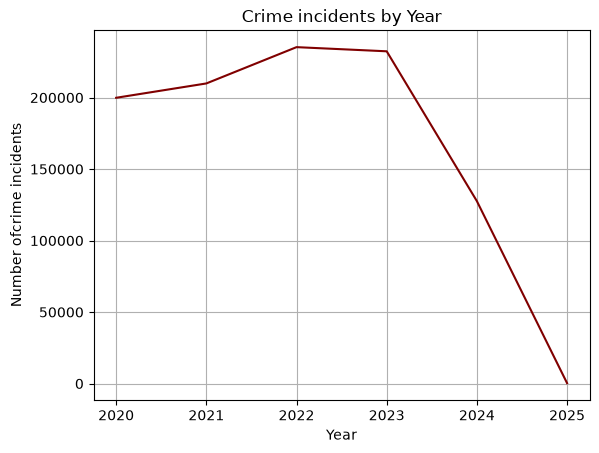

In [16]:
year_ana = df['Year'].value_counts().sort_index()
year_ana

year_ana.plot(kind = 'line',
              color='maroon',
              title = 'Crime incidents by Year', 
              ylabel = 'Number ofcrime incidents',
              grid = True);

### Interpretation 3:

Crime incidents increased from 2020 to 2022, where 2022 recorded the highest number of reported incidents. The number remained high in 2023 before decreasing in 2024. The low number of incidents in 2025 is likely because the dataset contains only a small portion of records for that year.

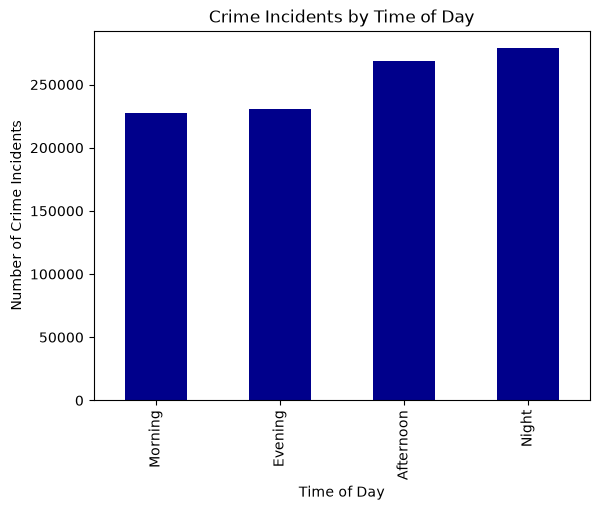

In [17]:
df['Time of Day'].value_counts(ascending = True).plot(kind='bar',
                                        color='darkblue',
                                        title='Crime Incidents by Time of Day',
                                        xlabel='Time of Day',
                                        ylabel='Number of Crime Incidents');

### Interpretation 4:

Most crimes were reported during the night, followed by the afternoon, while crimes happens the least in the morning. This suggests that crimes are reported more frequently during the later hours of the day.

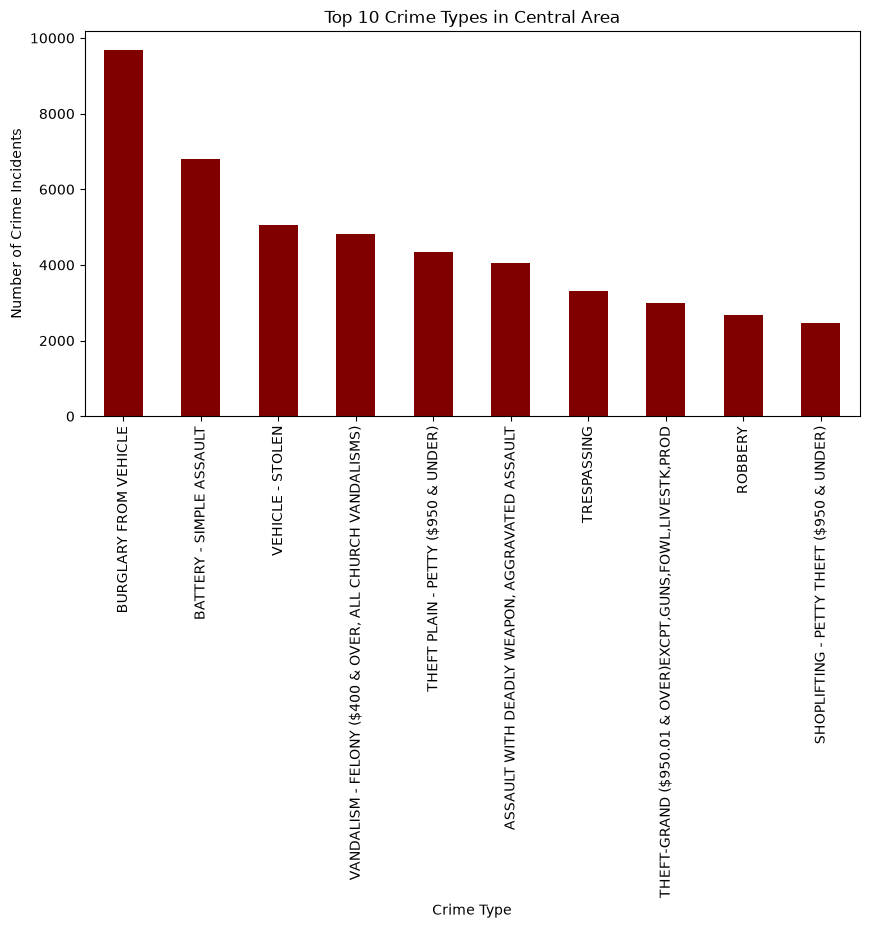

In [18]:
central = df[df['AREA NAME'] == 'Central']
central['Crm Cd Desc'].value_counts().head(10)

central['Crm Cd Desc'].value_counts().head(10).plot(kind='bar',
                                                    color='Maroon',
                                                    title='Top 10 Crime Types in Central Area',
                                                    xlabel='Crime Type',
                                                    ylabel='Number of Crime Incidents',
                                                    figsize=(10,5));

### Interpretation 5:

Burglary from vehicle was the most frequently reported crime in the Central area, followed by battery - simple assault and vehicle theft. This suggests that vehicle-related crimes are among the most common crimes reported in the Central area.

---

## Summary
__Summarizing the key insights from the analysis__

- More than one million crime incidents were analyzed.
- Vehicle theft was the most common reported crime.
- Central had the highest number of crime incidents.
- Crime incidents peaked in 2022.
- Most crimes were reported during the night.
- Vehicle-related crimes were common in the Central area.

## Recommendations/Conclusion

### Recommendations

- Increase police patrols in high-crime areas, especially Central.
- Improve vehicle theft prevention through public awareness.
- Increase police presence during nighttime hours.
- Continue monitoring crime trends to support future decision-making.


### Conclusion

This project showed how exploratory data analysis can be used to understand crime patterns in Los Angeles. By analyising crime types, locations and time trends, the project identified important patterns that can support better public safety decisions in the future.